# K-Means

This notebook is a hands-on practice of K-Means clustering algorithm

Datasets used:
 - https://www.kaggle.com/datasets/himanshunakrani/iris-dataset
 - https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python



In [27]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

iris_df = pd.read_csv("./data/iris.csv")
mall_df = pd.read_csv("./data/Mall_Customers.csv", index_col="CustomerID")

mall_df.head()


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


,Gender,Age,Annual Income (k$),Spending Score (1-100)
CustomerID,,,,
1,Male,19,15,39
2,Male,21,15,81
3,Female,20,16,6
4,Female,23,16,77
5,Female,31,17,40


# 1. K-Means from scratch

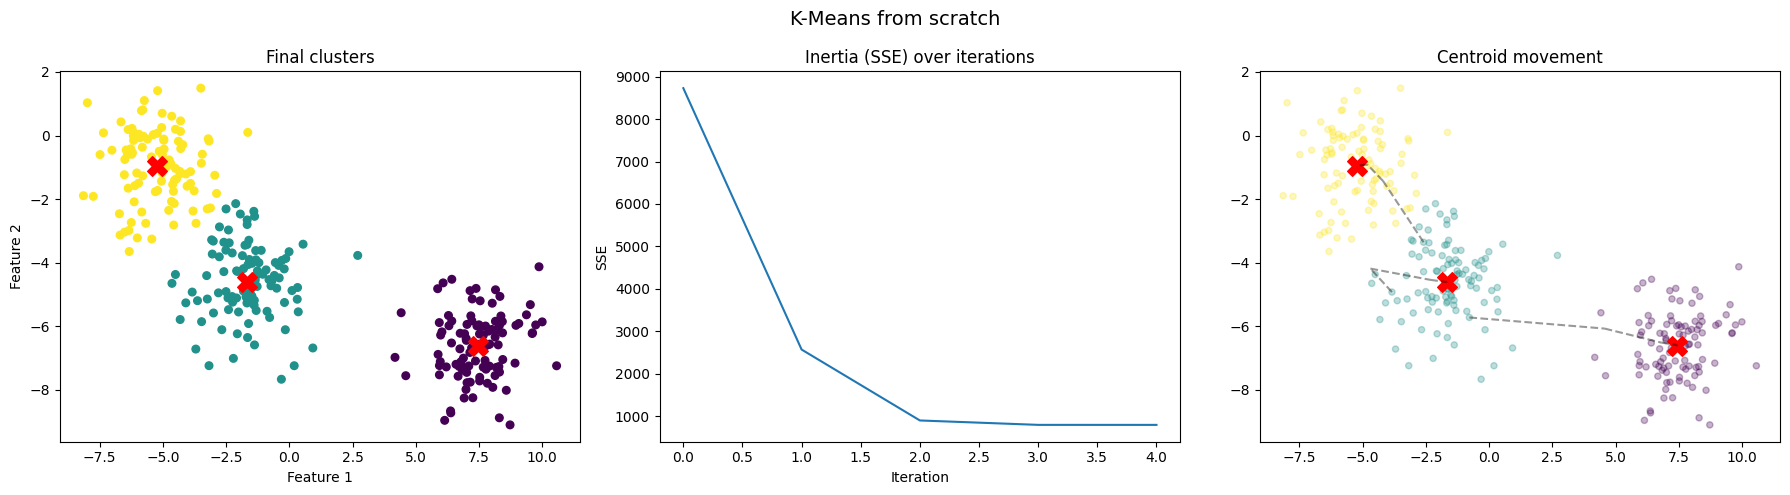

In [28]:
from mlpeople.models.clustering.kmeans import kmeans_from_scratch
from mlpeople.models.clustering.visualization import plot_kmeans_result
from sklearn.datasets import make_blobs

X, _ = make_blobs(n_samples=300, centers=3, cluster_std=1.2, random_state=33)

centroids, labels, history = kmeans_from_scratch(X, k=3, random_state=33)
plot_kmeans_result(X, centroids, labels, history)

# 2. Iris — easy win

In [40]:
# Step 1 — Prepare data (2 features only for easy visualization) 
features = ["petal_length", "petal_width"]

X = iris_df[features].values
y = iris_df["species"].values  # only for comparison later

In [41]:
# Step 2 (optional) — scale features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [42]:
# Step 3 — Run K-Means from scratch
from mlpeople.models.clustering.kmeans import kmeans_from_scratch

centroids, labels, history = kmeans_from_scratch(
    X_scaled,
    k=3,
    random_state=42
)

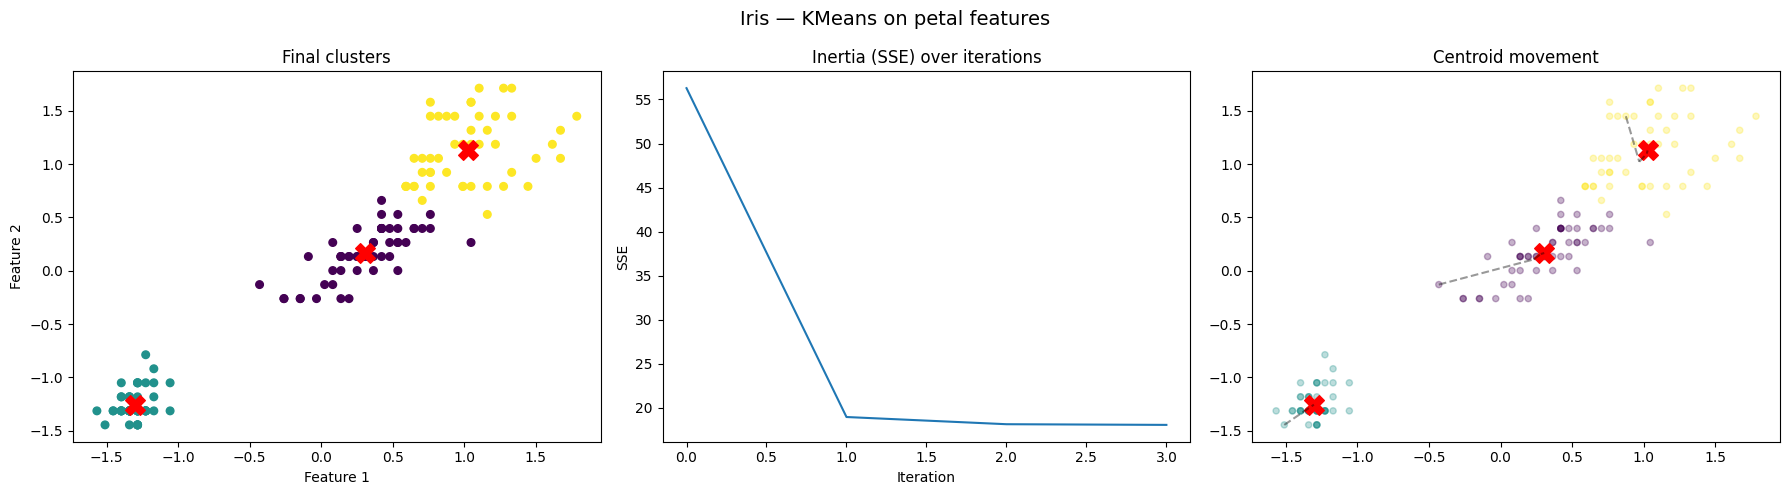

In [43]:
# Step 4 — Visualize clusters
from mlpeople.models.clustering.visualization import plot_kmeans_result

plot_kmeans_result(
    X_scaled,
    centroids,
    labels,
    history,
    title="Iris — KMeans on petal features"
)

In [44]:
# Step 5 — Compare clusters vs real species
import pandas as pd

comparison = pd.DataFrame({
    "cluster": labels,
    "species": y
})

pd.crosstab(comparison["cluster"], comparison["species"])

species,setosa,versicolor,virginica
cluster,,,
0,0,48,4
1,50,0,0
2,0,2,46


In [45]:
def cluster_purity(labels, true_labels):
    df = pd.DataFrame({"cluster": labels, "true": true_labels})
    total = 0
    for _, group in df.groupby("cluster"):
        total += group["true"].value_counts().max()
    return total / len(df)

cluster_purity(labels, y)

np.float64(0.96)

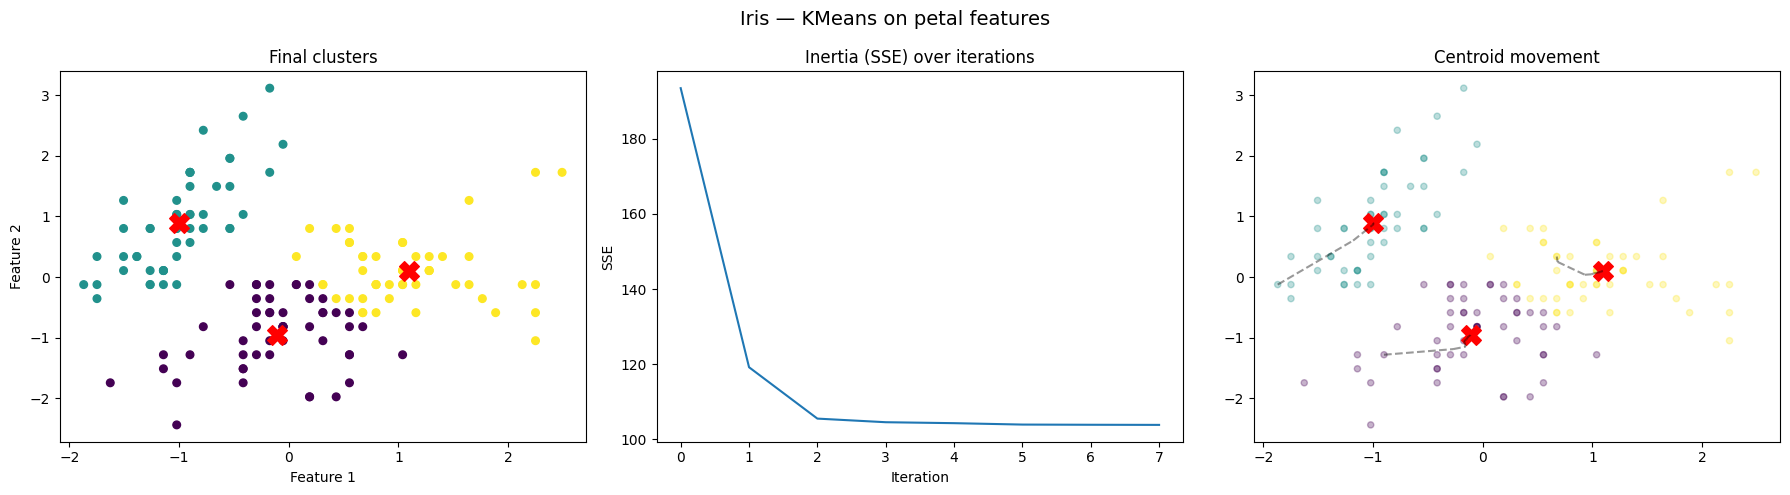

species,setosa,versicolor,virginica
cluster,,,
0,1,34,16
1,49,0,0
2,0,16,34


np.float64(0.78)

In [48]:
# same with 2 other features
features = ["sepal_length", "sepal_width"]

X = iris_df[features].values
y = iris_df["species"].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

centroids, labels, history = kmeans_from_scratch(
    X_scaled,
    k=3,
    random_state=42
)

plot_kmeans_result(
    X_scaled,
    centroids,
    labels,
    history,
    title="Iris — KMeans on petal features"
)

comparison = pd.DataFrame({
    "cluster": labels,
    "species": y
})

display(pd.crosstab(comparison["cluster"], comparison["species"]))

cluster_purity(labels, y)

# 3. Mall — real segmentation

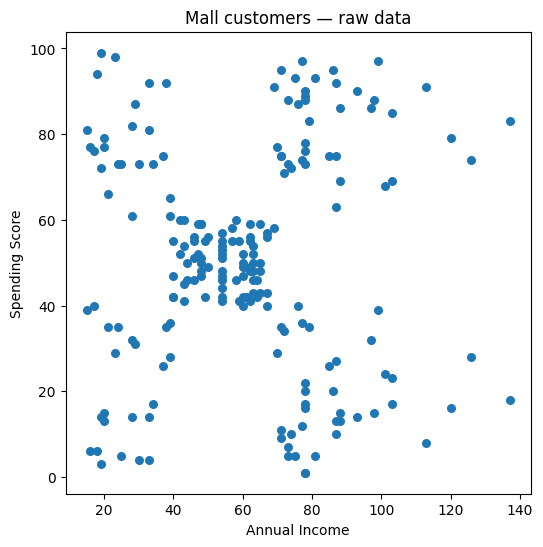

In [49]:
# Step 1 — Select features
features = ["Annual Income (k$)", "Spending Score (1-100)"]

X = mall_df[features].values

# Step 2 — Visualize raw data first
plt.figure(figsize=(6, 6))
plt.scatter(X[:, 0], X[:, 1], s=30)
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Mall customers — raw data")
plt.show()

In [50]:
# Step 3 — Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 4 — Run K-Means for multiple K
inertias = []

for k in range(2, 11):
    centroids, labels, history = kmeans_from_scratch(
        X_scaled, k=k, random_state=42
    )
    inertias.append(history["inertia"][-1])

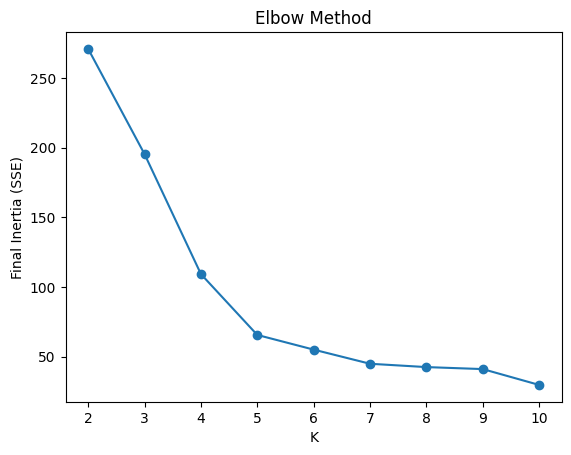

In [51]:
# Step 5 — Elbow method
plt.plot(range(2, 11), inertias, marker='o')
plt.xlabel("K")
plt.ylabel("Final Inertia (SSE)")
plt.title("Elbow Method")
plt.show()

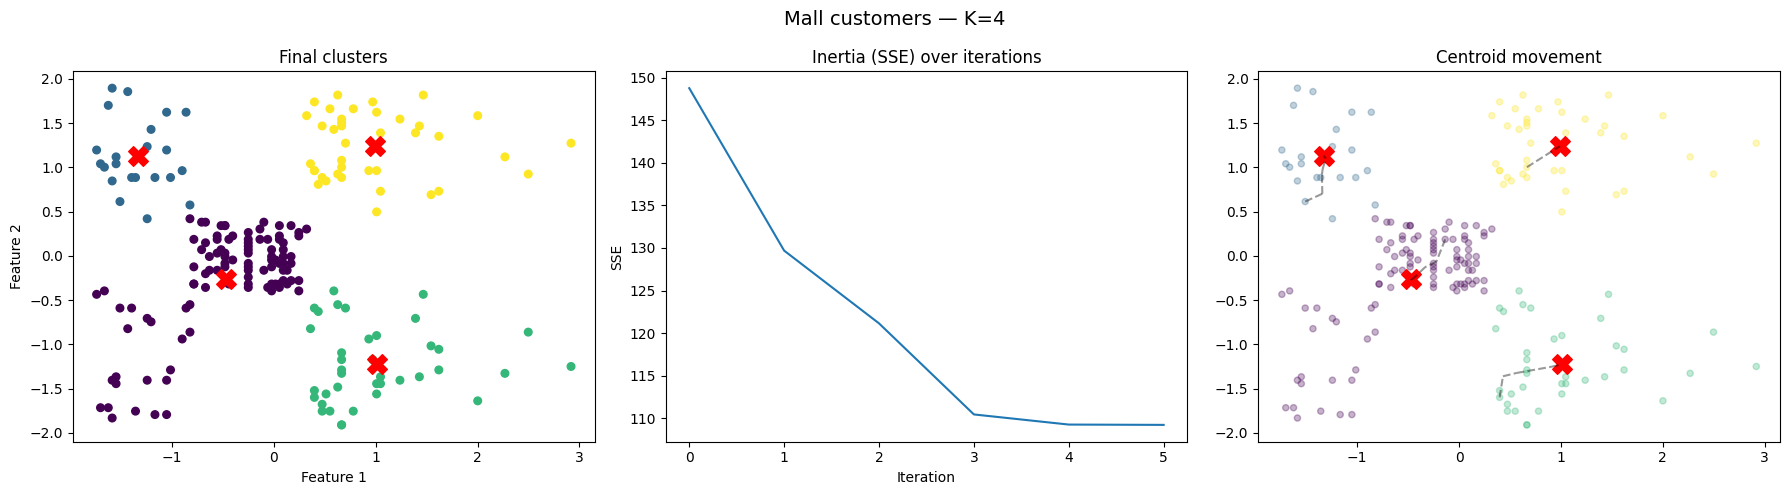

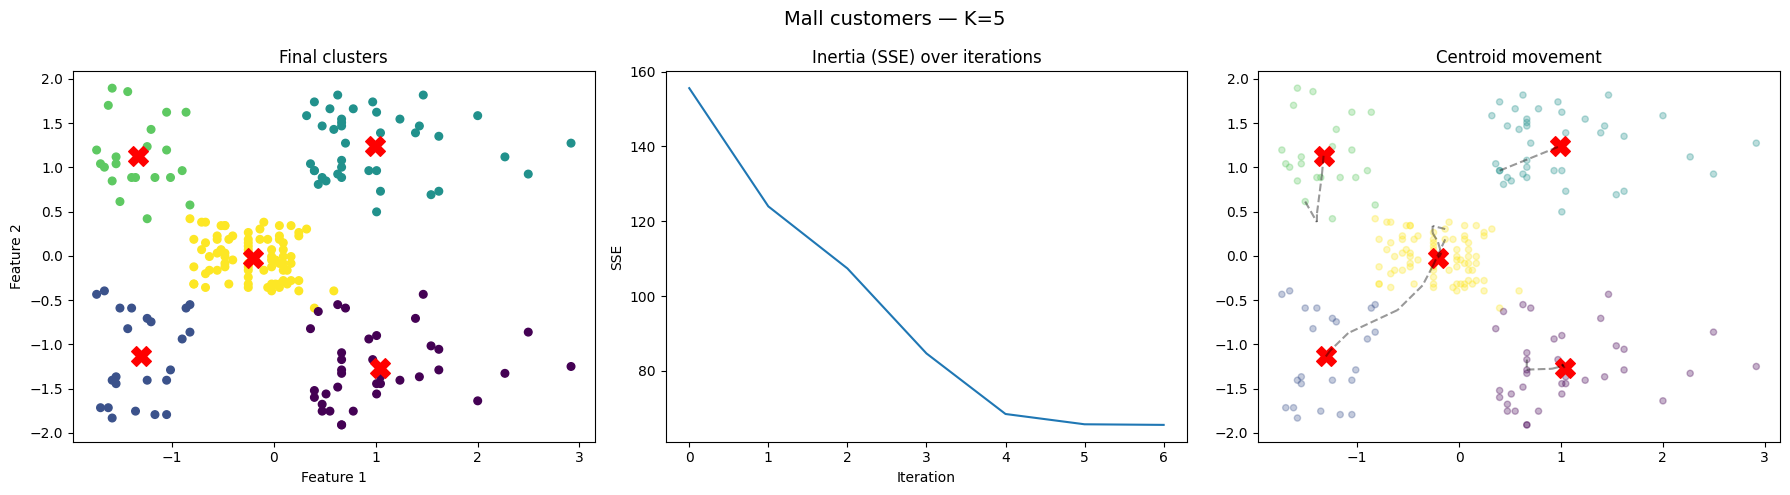

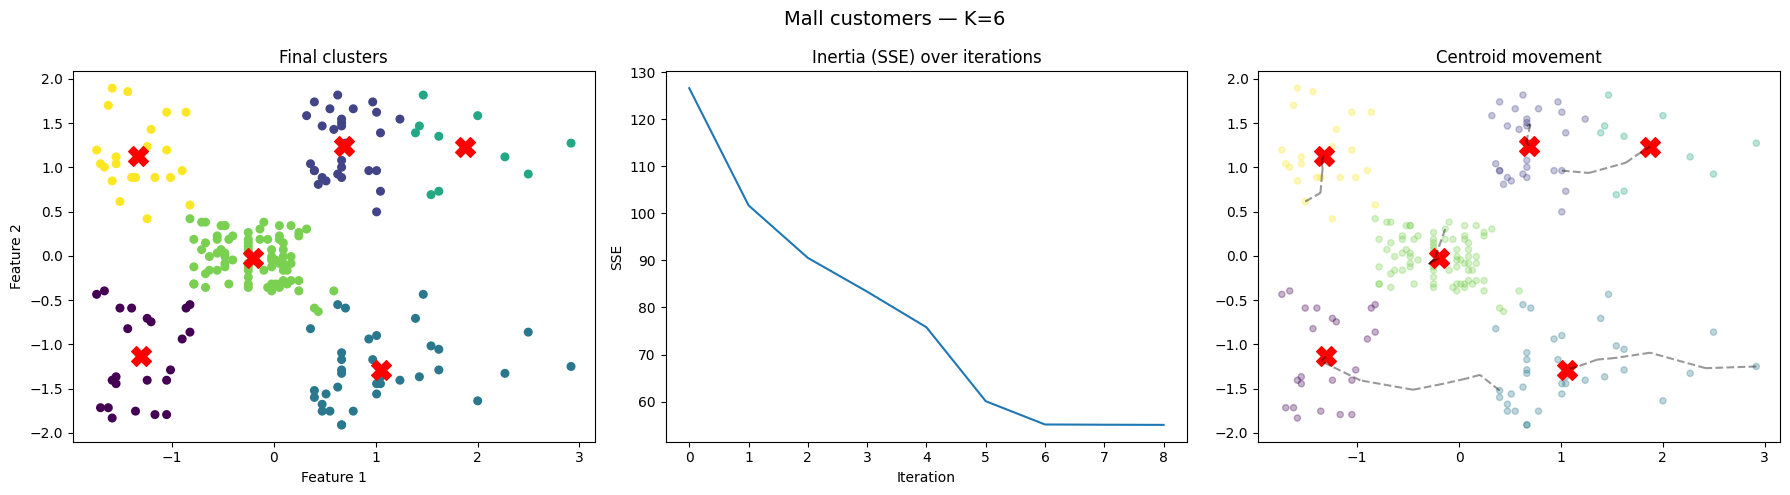

In [52]:
# Step 6 — Visually inspect different K
for k in [4, 5, 6]:
    centroids, labels, history = kmeans_from_scratch(
        X_scaled, k=k, random_state=42
    )
    
    plot_kmeans_result(
        X_scaled,
        centroids,
        labels,
        history,
        title=f"Mall customers — K={k}"
    )

## Interpret clusters

| Cluster | Income level | Spending level | What we actually know            | Potential Interpretation             |
| ------- | ------------ | -------------- | -------------------------------- | ------------------------------------ |
| C0      | Low          | Low            | Low income, low spending score   | Low value customers        |
| C1      | Low          | High           | Low income, high spending score  | Impulsive / young shoppers |
| C2      | High         | Low            | High income, low spending score  | Rich but careful           |
| C3      | High         | High           | High income, high spending score | Premium customers          |
| C4      | Mid          | Mid            | Moderate income and spending     | Average shoppers           |



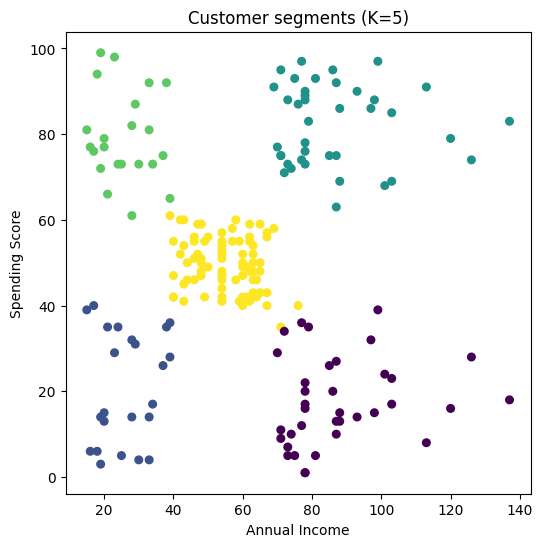

In [54]:
# Step 7 — Show clusters on original (unscaled) axes
centroids, labels, _ = kmeans_from_scratch(X_scaled, k=5, random_state=42)

plt.figure(figsize=(6, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels, s=30)
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer segments (K=5)")
plt.show()